<a href="https://colab.research.google.com/github/r73psv/univer/blob/master/avdoshin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium box2d-py pygame
!pip install torch --index-url https://download.pytorch.org/whl/cpu
!pip install stable-baselines3[extra]
!pip install numpy numba matplotlib
!pip install matplotlib pandas
!pip install swig
!pip install gymnasium[box2d]

  Using cached box2d-py-2.3.8.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for box2d-py
  Running setup.py clean for box2d-py
Failed to build box2d-py
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (box2d-py)
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached swig-4.3.1.post0-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
Using cached swig-4.3.1.post0-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.9 MB)
  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2409499 sha256=c48afef25f311d0b0664b27d6

In [ ]:
import gymnasium as gym

import numpy as np
import os, random, math, time
import matplotlib.pyplot as plt
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# Две разные среды
env_names = ["LunarLander-v3", "Pendulum-v1"]

print("=" * 60)
print("СРАВНЕНИЕ ДВУХ РАЗНЫХ СРЕД RL")
print("=" * 60)

for name in env_names:
    env = gym.make(name)
    print(f"\n АНАЛИЗ СРЕДЫ: {name}")
    print("-" * 40)

    # Получаем информацию о среде
    observation, info = env.reset()

    print(f" Пространство наблюдений: {env.observation_space}")
    print(f" Пространство действий: {env.action_space}")
    print(f" Размер наблюдения: {len(observation)}")
    print(f" Пример наблюдения: {observation}")

    # Демонстрация нескольких шагов
    print(f"\n Демонстрация 3 шагов:")
    total_reward = 0
    for step in range(3):
        action = env.action_space.sample()  # Случайное действие
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        print(f"     Шаг {step+1}:")
        print(f"     Действие: {action}")
        print(f"     Награда: {reward:.2f}")
        print(f"     Завершено: {terminated}")
        print(f"     Новое наблюдение: {observation}")

        if terminated or truncated:
            break

    print(f" Суммарная награда: {total_reward:.2f}")

    env.close()

print("\n" + "=" * 60)
print(" СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("=" * 60)

# Создаем сравнительную таблицу
comparison_data = []

for name in env_names:
    env = gym.make(name)
    observation, info = env.reset()

    comparison_data.append({
        "Название": name,
        "Тип задачи": "Оптимизации траектории" if "LunarLander" in name else "Достижение цели",
        "Наблюдения": env.observation_space.shape[0],
        "Действия": env.action_space.n if hasattr(env.action_space, 'n') else "Непрерывное",
        "Цель": "Приземлиться с первой попытки" if "LunarLander" in name else "Привести в вертикальное положение ",
        "Сложность": "Средняя" if "LunarLander" in name else "Сложная"
    })

    env.close()

# Выводим таблицу сравнения
print(f"{'Название':<15} {'Тип задачи':<15} {'Наблюдения':<12} {'Действия':<15} {'Цель':<30} {'Сложность':<10}")
print("-" * 100)
for data in comparison_data:
    print(f"{data['Название']:<15} {data['Тип задачи']:<15} {data['Наблюдения']:<12} {data['Действия']:<15} {data['Цель']:<30} {data['Сложность']:<10}")

print("\n" + "=" * 60)
print("ВЫВОДЫ:")
print("=" * 60)
print("1. LunarLander-v3 - задача оптимизации траектории с дискретными действиями")
print("2. Pendulum-v1 - задача достижения цели с непрерывным действием")
print("3. Разный размер пространства наблюдений и действий")
print("4. Разные механики награды и условия завершения эпизода")

СРАВНЕНИЕ ДВУХ РАЗНЫХ СРЕД RL

 АНАЛИЗ СРЕДЫ: LunarLander-v3
----------------------------------------
 Пространство наблюдений: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
 Пространство действий: Discrete(4)
 Размер наблюдения: 8
 Пример наблюдения: [ 0.00248823  1.4005198   0.25201398 -0.46223962 -0.00287645 -0.0570849
  0.          0.        ]

 Демонстрация 3 шагов:
     Шаг 1:
     Действие: 2
     Награда: 2.52
     Завершено: False
     Новое наблюдение: [ 0.00502329  1.3907142   0.25613302 -0.4358085  -0.00548303 -0.05213602
  0.          0.        ]
     Шаг 2:
     Действие: 2
     Награда: 0.25
     Завершено: False
     Новое наблюдение: [ 0.00768051  1.3810099   0.26777896 -0.43131214 -0.0075132  -0.04060686
  0.          0.        ]
     Шаг 3:
     Действие: 2
     Награда: 2.53
     Завершено: False
     Новое наблюдение

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import DQN, PPO, A2C,SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import time
import os
import torch

# Создаем директорию для сохранения моделей
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Две разные среды
env_names = ["LunarLander-v3", "Pendulum-v1"]
algo_cartpole = {
    "DQN": DQN,
    "PPO": PPO,
    "A2C": A2C

}

algo_pendulum = {
    "PPO": PPO,
    "A2C": A2C,
    "SAC": SAC

}
# Функция обучения и тестирования алгоритмов
def learning(name):
         # Обучение
        start_time = time.time()
        model.learn(total_timesteps=TOTAL_TIMESTEPS)
        training_time = time.time() - start_time

        # Сохраняем модель
        model_path = f"models/{env_name}_{algo_name}"
        model.save(model_path)

        # Оценка политики
        mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=EVAL_EPISODES)

        # Демонстрация одного эпизода
        print(f"      Результаты оценки:")
        print(f"      Средняя награда: {mean_reward:.2f} ± {std_reward:.2f}")
        print(f"      Время обучения: {training_time:.2f} сек")

        # Демонстрация одного эпизода
        obs, _ = env.reset()
        total_reward = 0
        steps = 0
        terminated = False
        truncated = False

        while not (terminated or truncated) and steps < 200:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        print(f"    Демо-эпизод: награда = {total_reward}, шагов = {steps}")

        env_results[algo_name] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward,
            'training_time': training_time,
            'demo_reward': total_reward,
            'demo_steps': steps
        }

        env.close()

        results[env_name] = env_results

print("=" * 80)
print("СРАВНЕНИЕ АЛГОРИТМОВ RL НА РАЗНЫХ СРЕДАХ")
print("=" * 80)

# Параметры обучения
TOTAL_TIMESTEPS = 10000
EVAL_EPISODES = 10

results = {}

for env_name in env_names:
    print(f"\n ТЕСТИРУЕМ СРЕДУ: {env_name}")
    print("=" * 50)

    env_results = {}
    env = gym.make(env_name)
    if  "LunarLander" in env_name:

        for algo_name, algo_class in algo_cartpole.items():
            print(f"\n АЛГОРИТМ: {algo_name}")
            print("-" * 30)

          # Настройки для среды и алгоритмов
            if algo_name == "DQN":
                model = algo_class('MlpPolicy', env, verbose=0, learning_rate=1e-3,
                                 buffer_size=10000, exploration_fraction=0.1)

            elif algo_name == "PPO":
                model = algo_class('MlpPolicy', env, verbose=0, learning_rate=2.5e-4)

            else:  # A2C
                model = algo_class('MlpPolicy', env, verbose=0, learning_rate=7e-4)

            # обучение и тестирование
            learning(algo_name)

    else:

        for algo_name, algo_class in algo_pendulum.items():
            print(f"\n АЛГОРИТМ: {algo_name}")
            print("-" * 30)

           # Настройки для среды и алгоритмов
            if algo_name == "SAC":
               model = algo_class("MlpPolicy", env, verbose=0, learning_rate=1e-4,
                                  device="cuda" if torch.cuda.is_available() else "cpu") # проверка доступности cuda

            elif algo_name == "PPO":
               model = algo_class('MlpPolicy', env, verbose=0, learning_rate=1e-4)

            else:  # A2C
              model = algo_class('MlpPolicy', env, verbose=0, learning_rate=7e-4)

            # обучение и тестирование
            learning(algo_name)



print("\n" + "=" * 80)
print("  СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)

# Выводим сравнительную таблицу
for env_name in env_names:
    print(f"\n   СРЕДА: {env_name}")
    print("-" * 60)
    print(f"{'Алгоритм':<10} {'Ср. награда':<12} {'Отклонение':<12} {'Время обучения':<15} {'Демо-награда':<12} {'Демо-шаги':<10}")
    print("-" * 60)
    if  "LunarLander" in env_name:
        for algo_name in algo_cartpole.keys():
            data = results[env_name][algo_name]
            print(f"{algo_name:<10} {data['mean_reward']:>11.2f} {data['std_reward']:>11.2f} "
                f"{data['training_time']:>14.2f}с {data['demo_reward']:>11.2f} {data['demo_steps']:>9}")
    else:
       for algo_name in algo_pendulum.keys():
            data = results[env_name][algo_name]
            print(f"{algo_name:<10} {data['mean_reward']:>11.2f} {data['std_reward']:>11.2f} "
                f"{data['training_time']:>14.2f}с {data['demo_reward']:>11.2f} {data['demo_steps']:>9}")

print("\n" + "=" * 80)
print(" АНАЛИЗ ПРОИЗВОДИТЕЛЬНОСТИ АЛГОРИТМОВ")
print("=" * 80)

# Анализ производительности
for env_name in env_names:
    print(f"\n АНАЛИЗ ДЛЯ {env_name}:")

    # Находим лучший алгоритм по средней награде
    best_algo = max(results[env_name].items(), key=lambda x: x[1]['mean_reward'])
    worst_algo = min(results[env_name].items(), key=lambda x: x[1]['mean_reward'])

    print(f"    Лучший алгоритм: {best_algo[0]} (награда: {best_algo[1]['mean_reward']:.2f})")
    print(f"    Худший алгоритм: {worst_algo[0]} (награда: {worst_algo[1]['mean_reward']:.2f})")

    # Сравнение времени обучения
    fastest_algo = min(results[env_name].items(), key=lambda x: x[1]['training_time'])
    slowest_algo = max(results[env_name].items(), key=lambda x: x[1]['training_time'])

    print(f"    Самый быстрый: {fastest_algo[0]} ({fastest_algo[1]['training_time']:.2f}с)")
    print(f"    Самый медленный: {slowest_algo[0]} ({slowest_algo[1]['training_time']:.2f}с)")

print("\n" + "=" * 80)
print(" ВЫВОДЫ:")
print("=" * 80)

print("\n1. СРАВНЕНИЕ АЛГОРИТМОВ:")
print("   • DQN: Работает с дискретными действиями, стабильное обучение")
print("   • PPO: Универсальный алгоритм, хорош для непрерывных и дискретных действий")
print("   • A2C: Быстрое обучение, но может быть менее стабильным")
print("   • SAC: Работает с непрерывными действиями, стабильное обучение")

print("\n2. ПОВЕДЕНИЕ НА РАЗНЫХ СРЕДАХ:")
print("   • LunarLander-v3: Все алгоритмы показывают хорошие результаты")
print("   • Pendulum-v1: Более сложная среда, требует больше времени для обучения")
print("   • Разные алгоритмы требуют разных гиперпараметров для разных сред")

print("\n3. ПРОИЗВОДИТЕЛЬНОСТЬ:")
print("   • Время обучения варьируется между алгоритмами")
print("   • Стабильность результатов отличается между запусками")
print("   • Не существует 'универсального лучшего' алгоритма для всех сред")

# Дополнительный анализ характеристик сред
print("\n" + "=" * 80)
print(" ДЕТАЛЬНЫЙ АНАЛИЗ ХАРАКТЕРИСТИК СРЕД")
print("=" * 80)

for env_name in env_names:
    env = gym.make(env_name)
    observation, info = env.reset()

    print(f"\n {env_name}:")
    print(f"   • Пространство наблюдений: {env.observation_space}")
    print(f"   • Пространство действий: {env.action_space}")
    print(f"   • Размер наблюдения: {len(observation)}")

    if hasattr(env.action_space, 'n'):
        print(f"   • Тип действий: Дискретные ({env.action_space.n} действий)")
    else:
        print(f"   • Тип действий: Непрерывные")

    env.close()

СРАВНЕНИЕ АЛГОРИТМОВ RL НА РАЗНЫХ СРЕДАХ

 ТЕСТИРУЕМ СРЕДУ: LunarLander-v3

 АЛГОРИТМ: DQN
------------------------------


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


      Результаты оценки:
      Средняя награда: -96.12 ± 102.12
      Время обучения: 14.91 сек
    Демо-эпизод: награда = -40.71452914968338, шагов = 200

 АЛГОРИТМ: PPO
------------------------------
      Результаты оценки:
      Средняя награда: -350.75 ± 151.69
      Время обучения: 19.01 сек
    Демо-эпизод: награда = -411.2474837448645, шагов = 187

 АЛГОРИТМ: A2C
------------------------------
      Результаты оценки:
      Средняя награда: -206.46 ± 210.22
      Время обучения: 21.67 сек
    Демо-эпизод: награда = -56.57030626012107, шагов = 200

 ТЕСТИРУЕМ СРЕДУ: Pendulum-v1

 АЛГОРИТМ: PPO
------------------------------
      Результаты оценки:
      Средняя награда: -1100.99 ± 173.86
      Время обучения: 16.14 сек
    Демо-эпизод: награда = -850.8450814431387, шагов = 200

 АЛГОРИТМ: A2C
------------------------------
      Результаты оценки:
      Средняя награда: -1729.19 ± 120.54
      Время обучения: 19.89 сек
    Демо-эпизод: награда = -1571.8612994110804, шагов = 200

  ДАТАФРЕЙМ С РЕЗУЛЬТАТАМИ:
            Среда Алгоритм  Средняя награда  Ст. отклонение  Время обучения
0  LunarLander-v3      DQN       -96.115820      102.117360       14.907549
1  LunarLander-v3      PPO      -350.754965      151.693996       19.005275
2  LunarLander-v3      A2C      -206.458688      210.219035       21.669877
3     Pendulum-v1      PPO     -1100.994110      173.855610       16.140341
4     Pendulum-v1      A2C     -1729.186231      120.542753       19.888806
5     Pendulum-v1      SAC       -98.132053       91.486586      308.862603




/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


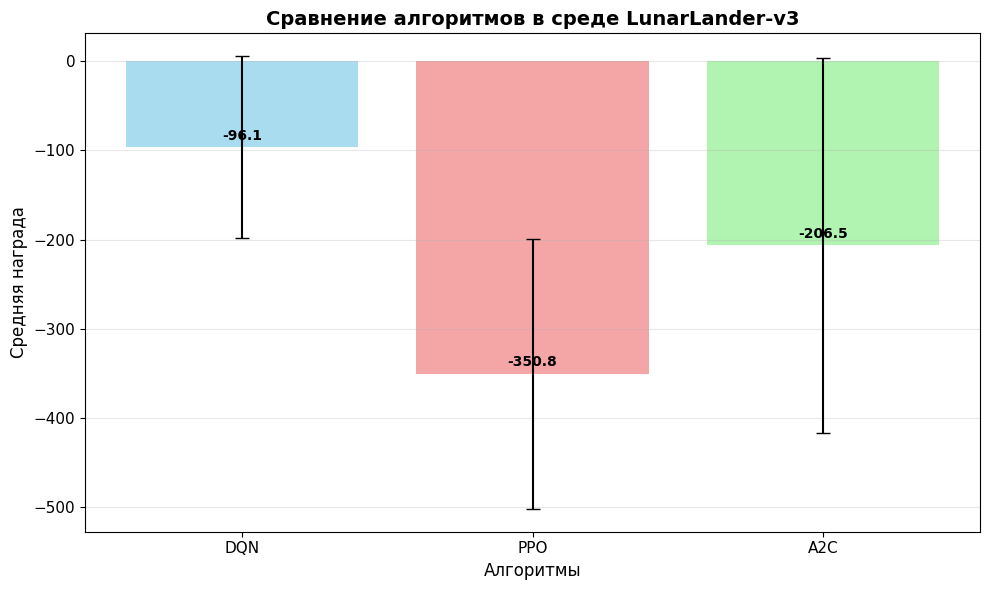

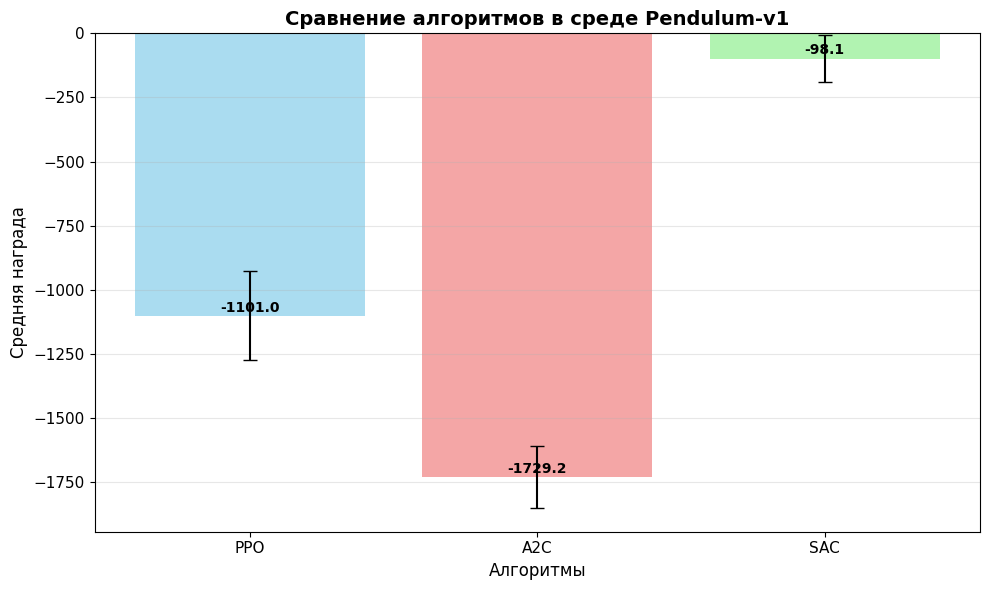

 ВРЕМЯ ОБУЧЕНИЯ АЛГОРИТМОВ:


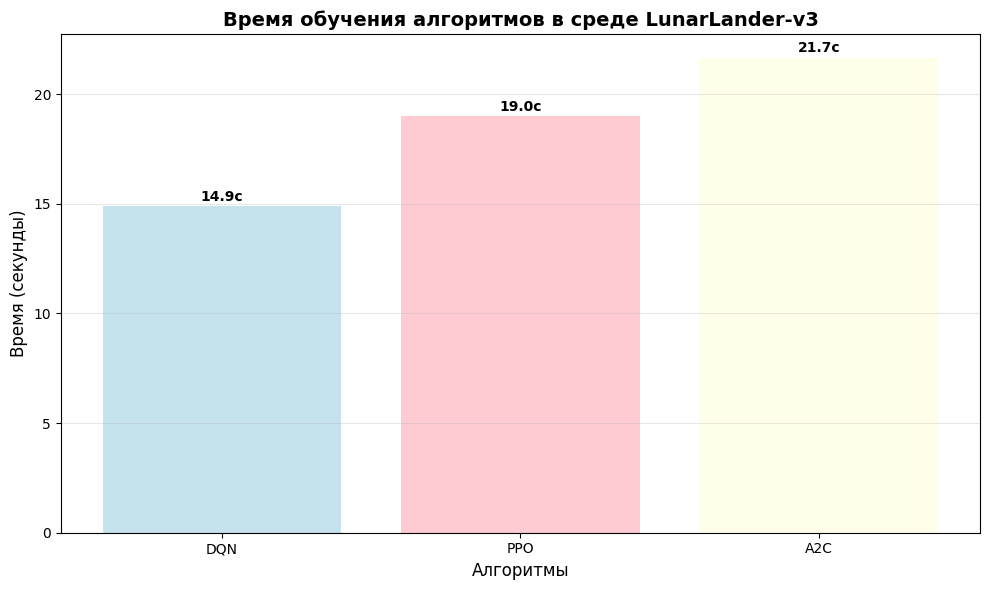

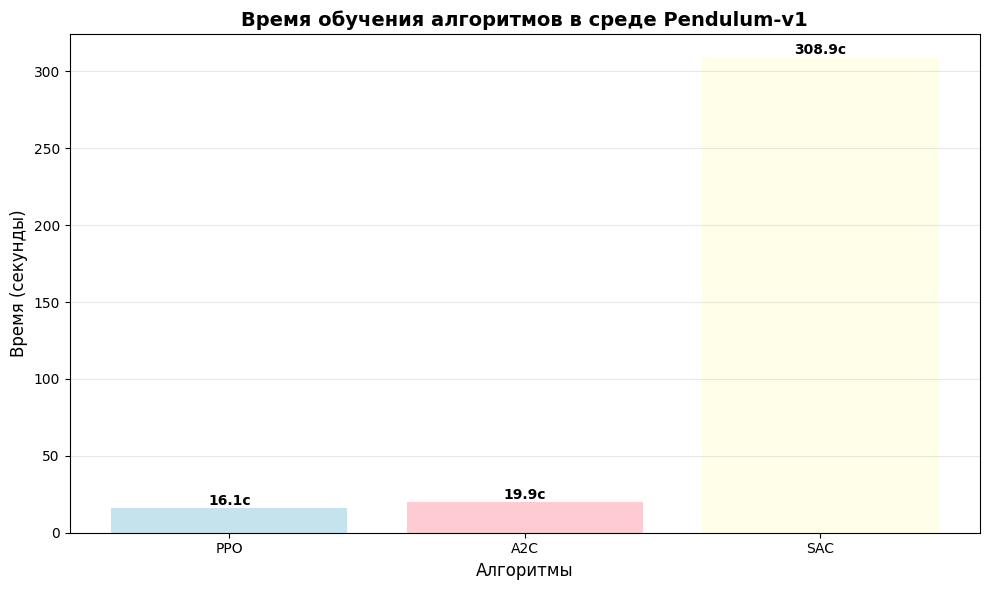

 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
         Средняя награда             Время обучения            
Среда     LunarLander-v3 Pendulum-v1 LunarLander-v3 Pendulum-v1
Алгоритм                                                       
A2C              -206.46    -1729.19          21.67       19.89
DQN               -96.12         NaN          14.91         NaN
PPO              -350.75    -1100.99          19.01       16.14
SAC                  NaN      -98.13            NaN      308.86


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

# Создаем DataFrame из результатов
results_list = []
for env_name in env_names:
  if  "LunarLander" in env_name:
    for algo_name in algo_cartpole.keys():
        result_data = results[env_name][algo_name]
        results_list.append({
            'Среда': env_name,
            'Алгоритм': algo_name,
            'Средняя награда': result_data['mean_reward'],
            'Ст. отклонение': result_data['std_reward'],
            'Время обучения': result_data['training_time']
        })
  else:
    for algo_name in algo_pendulum.keys():
        result_data = results[env_name][algo_name]
        results_list.append({
            'Среда': env_name,
            'Алгоритм': algo_name,
            'Средняя награда': result_data['mean_reward'],
            'Ст. отклонение': result_data['std_reward'],
            'Время обучения': result_data['training_time']
        })

df = pd.DataFrame(results_list)
print("  ДАТАФРЕЙМ С РЕЗУЛЬТАТАМИ:")
print("=" * 50)
print(df)
print("\n")

# Визуализация для каждой среды
for env_name in env_names:
    plt.figure(figsize=(10, 6))

    # Фильтруем данные для текущей среды
    subset = df[df["Среда"] == env_name]

    # Создаем столбчатую диаграмму с ошибками
    bars = plt.bar(subset["Алгоритм"], subset["Средняя награда"],
                   yerr=subset["Ст. отклонение"],
                   capsize=5, alpha=0.7,
                   color=['skyblue', 'lightcoral', 'lightgreen'])

    # Добавляем значения на столбцы
    for bar, value in zip(bars, subset["Средняя награда"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.title(f"Сравнение алгоритмов в среде {env_name}", fontsize=14, fontweight='bold')
    plt.ylabel("Средняя награда", fontsize=12)
    plt.xlabel("Алгоритмы", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    # Настройка внешнего вида
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    plt.tight_layout()
    plt.show()

# Дополнительная визуализация: время обучения
print(" ВРЕМЯ ОБУЧЕНИЯ АЛГОРИТМОВ:")
print("=" * 50)

for env_name in env_names:
    plt.figure(figsize=(10, 6))

    subset = df[df["Среда"] == env_name]

    bars = plt.bar(subset["Алгоритм"], subset["Время обучения"],
                   color=['lightblue', 'lightpink', 'lightyellow'],
                   alpha=0.7)

    # Добавляем значения на столбцы
    for bar, value in zip(bars, subset["Время обучения"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{value:.1f}с', ha='center', va='bottom', fontweight='bold')

    plt.title(f"Время обучения алгоритмов в среде {env_name}", fontsize=14, fontweight='bold')
    plt.ylabel("Время (секунды)", fontsize=12)
    plt.xlabel("Алгоритмы", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# Сводная таблица результатов
print(" СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("=" * 60)
summary_table = df.pivot(index='Алгоритм', columns='Среда',
                        values=['Средняя награда', 'Время обучения'])
print(summary_table.round(2))